#### **ENCODING CATEGORICAL FEATURES**

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [57]:
df2=pd.read_csv("cleaned_thyroid_risk_data.csv")
df2.head()

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [58]:

gender_encoder = OneHotEncoder(drop='first', sparse_output=False)

gender_encoded = gender_encoder.fit_transform(df2[['Gender']])

gender_encoded_df = pd.DataFrame(gender_encoded, columns=['Gender_Male'])

df2 = pd.concat([df2.drop('Gender', axis=1), gender_encoded_df], axis=1)

df2.head()


,Age,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis,Gender_Male
0,66,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign,1.0
1,29,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign,1.0
2,86,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign,1.0
3,75,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign,0.0
4,35,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign,0.0


In [59]:

diagnosis_encoder = OneHotEncoder(drop='first', sparse_output=False)

diagnosis_encoded = diagnosis_encoder.fit_transform(df2[['Diagnosis']])


diagnosis_columns = diagnosis_encoder.get_feature_names_out(['Diagnosis'])

diagnosis_encoded_df = pd.DataFrame(diagnosis_encoded, columns=diagnosis_columns)


df2 = pd.concat([df2.drop('Diagnosis', axis=1), diagnosis_encoded_df], axis=1)

# Check result
df2.head()


,Age,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
0,66,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,1.0,0.0
1,29,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,1.0,0.0
2,86,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,1.0,0.0
3,75,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,0.0,0.0
4,35,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,0.0,0.0


In [60]:
df2[['Family_History',	'Radiation_Exposure',	'Iodine_Deficiency',	'Smoking',	'Obesity',	'Diabetes']]

,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes
0,No,Yes,No,No,No,No
1,No,Yes,No,No,No,No
2,No,No,No,No,No,No
3,No,No,No,No,No,No
4,Yes,Yes,No,No,No,No
...,...,...,...,...,...,...
212686,No,No,No,No,Yes,No
212687,No,No,No,No,Yes,No
212688,No,No,No,No,No,Yes
212689,No,No,No,No,No,Yes


In [61]:
# Simple binary encoding using map()
df2['Family_History'] = df2['Family_History'].map({'Yes': 1, 'No': 0})
df2['Radiation_Exposure'] = df2['Radiation_Exposure'].map({'Yes': 1, 'No': 0})
df2['Iodine_Deficiency'] = df2['Iodine_Deficiency'].map({'Yes': 1, 'No': 0})
df2['Smoking'] = df2['Smoking'].map({'Yes': 1, 'No': 0})
df2['Obesity'] = df2['Obesity'].map({'Yes': 1, 'No': 0})
df2['Diabetes'] = df2['Diabetes'].map({'Yes': 1, 'No': 0})

# Check result
df2[['Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']].head()


,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes
0,0,1,0,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,1,1,0,0,0,0


In [62]:
df2.head()

,Age,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
0,66,Russia,Caucasian,0,1,0,0,0,0,9.37,1.67,6.16,1.08,Low,1.0,0.0
1,29,Germany,Hispanic,0,1,0,0,0,0,1.83,1.73,10.54,4.05,Low,1.0,0.0
2,86,Nigeria,Caucasian,0,0,0,0,0,0,6.26,2.59,10.57,4.61,Low,1.0,0.0
3,75,India,Asian,0,0,0,0,0,0,4.10,2.62,11.04,2.46,Medium,0.0,0.0
4,35,Germany,African,1,1,0,0,0,0,9.10,2.11,10.71,2.11,High,0.0,0.0


In [63]:
df2['Diagnosis_Malignant'].value_counts()

Diagnosis_Malignant
0.0    163196
1.0     49495
Name: count, dtype: int64

In [64]:
# Map ordinal risk levels to integers
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df2['Thyroid_Cancer_Risk'] = df2['Thyroid_Cancer_Risk'].map(risk_mapping)

# Check if mapped correctly
df2['Thyroid_Cancer_Risk']


0         0
1         0
2         0
3         1
4         2
         ..
212686    0
212687    1
212688    1
212689    1
212690    0
Name: Thyroid_Cancer_Risk, Length: 212691, dtype: int64

In [65]:
df2.head()

,Age,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
0,66,Russia,Caucasian,0,1,0,0,0,0,9.37,1.67,6.16,1.08,0,1.0,0.0
1,29,Germany,Hispanic,0,1,0,0,0,0,1.83,1.73,10.54,4.05,0,1.0,0.0
2,86,Nigeria,Caucasian,0,0,0,0,0,0,6.26,2.59,10.57,4.61,0,1.0,0.0
3,75,India,Asian,0,0,0,0,0,0,4.10,2.62,11.04,2.46,1,0.0,0.0
4,35,Germany,African,1,1,0,0,0,0,9.10,2.11,10.71,2.11,2,0.0,0.0


In [66]:
df2.drop(columns='Country',inplace=True)
df2.head()

,Age,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
0,66,Caucasian,0,1,0,0,0,0,9.37,1.67,6.16,1.08,0,1.0,0.0
1,29,Hispanic,0,1,0,0,0,0,1.83,1.73,10.54,4.05,0,1.0,0.0
2,86,Caucasian,0,0,0,0,0,0,6.26,2.59,10.57,4.61,0,1.0,0.0
3,75,Asian,0,0,0,0,0,0,4.10,2.62,11.04,2.46,1,0.0,0.0
4,35,African,1,1,0,0,0,0,9.10,2.11,10.71,2.11,2,0.0,0.0


In [67]:
df2.drop(columns='Ethnicity',inplace=True)
df2.head()

,Age,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
0,66,0,1,0,0,0,0,9.37,1.67,6.16,1.08,0,1.0,0.0
1,29,0,1,0,0,0,0,1.83,1.73,10.54,4.05,0,1.0,0.0
2,86,0,0,0,0,0,0,6.26,2.59,10.57,4.61,0,1.0,0.0
3,75,0,0,0,0,0,0,4.10,2.62,11.04,2.46,1,0.0,0.0
4,35,1,1,0,0,0,0,9.10,2.11,10.71,2.11,2,0.0,0.0


In [68]:
df2

,Age,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
0,66,0,1,0,0,0,0,9.37,1.67,6.16,1.08,0,1.0,0.0
1,29,0,1,0,0,0,0,1.83,1.73,10.54,4.05,0,1.0,0.0
2,86,0,0,0,0,0,0,6.26,2.59,10.57,4.61,0,1.0,0.0
3,75,0,0,0,0,0,0,4.10,2.62,11.04,2.46,1,0.0,0.0
4,35,1,1,0,0,0,0,9.10,2.11,10.71,2.11,2,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,58,0,0,0,0,1,0,2.00,0.64,11.92,1.48,0,0.0,0.0
212687,89,0,0,0,0,1,0,9.77,3.25,7.30,4.46,1,1.0,0.0
212688,72,0,0,0,0,0,1,7.72,2.44,8.71,2.36,1,0.0,0.0
212689,85,0,0,0,0,0,1,5.62,2.53,9.62,1.54,1,0.0,0.0


In [69]:
df2.corr()

,Age,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Gender_Male,Diagnosis_Malignant
Age,1.000000,0.003337,0.004007,-0.002368,-0.000435,0.002233,-0.002590,-0.000925,-0.001013,-0.002373,-0.001489,0.003255,-0.000151,0.000115
Family_History,0.003337,1.000000,-0.000795,0.000550,-0.000406,0.000915,-0.000422,0.005014,0.001324,-0.000397,-0.002877,0.239961,-0.002121,0.140921
Radiation_Exposure,0.004007,-0.000795,1.000000,0.002381,0.001947,-0.002236,0.000158,0.000210,-0.003249,-0.000294,0.000118,0.146727,-0.000649,0.089043
Iodine_Deficiency,-0.002368,0.000550,0.002381,1.000000,0.001282,0.000592,-0.001800,-0.000824,0.000024,0.001326,-0.000033,0.169618,-0.002840,0.099032
Smoking,-0.000435,-0.000406,0.001947,0.001282,1.000000,-0.001899,-0.000151,-0.000869,0.001163,-0.000098,0.002523,-0.001657,-0.003239,0.000862
Obesity,0.002233,0.000915,-0.002236,0.000592,-0.001899,1.000000,0.000854,0.001318,-0.001064,0.002272,0.002850,-0.002468,-0.001941,-0.001233
Diabetes,-0.002590,-0.000422,0.000158,-0.001800,-0.000151,0.000854,1.000000,0.001751,0.001787,0.000569,-0.001913,-0.001021,-0.000641,-0.003218
TSH_Level,-0.000925,0.005014,0.000210,-0.000824,-0.000869,0.001318,0.001751,1.000000,0.000335,-0.000795,0.000416,0.002494,-0.000102,-0.002670
T3_Level,-0.001013,0.001324,-0.003249,0.000024,0.001163,-0.001064,0.001787,0.000335,1.000000,-0.004069,-0.001799,-0.000348,-0.003066,-0.002388
T4_Level,-0.002373,-0.000397,-0.000294,0.001326,-0.000098,0.002272,0.000569,-0.000795,-0.004069,1.000000,-0.001860,0.002761,-0.000114,0.001216


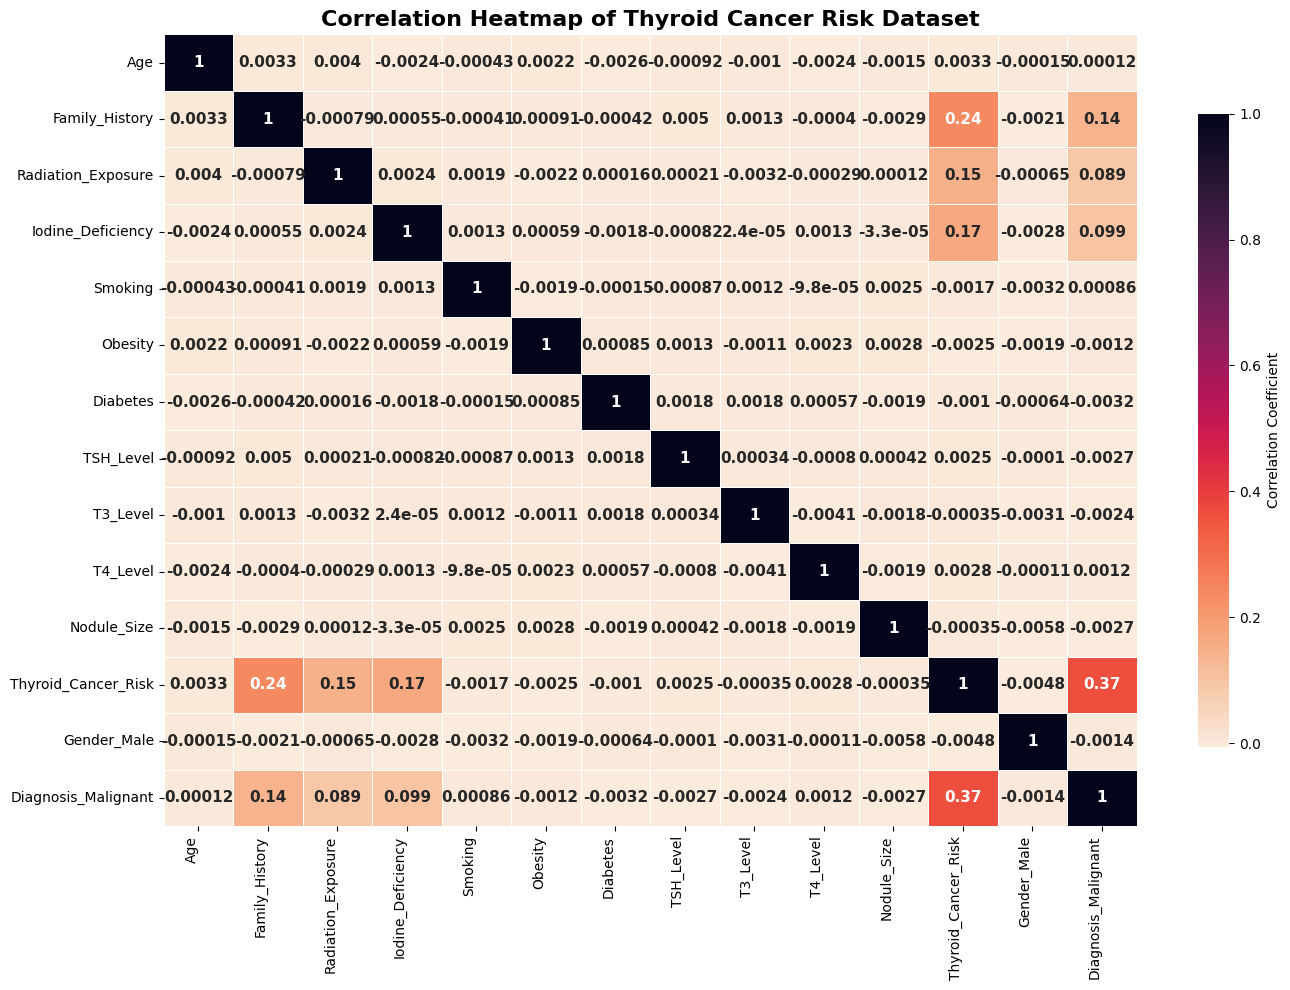

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df2.corr(method='pearson')

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    #fmt=".1f",
    cmap="rocket_r",           #rocket_r ,    
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 11, "weight": "bold"},
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)


plt.title("Correlation Heatmap of Thyroid Cancer Risk Dataset", fontsize=16, weight='bold')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


In [71]:
df2['Diagnosis_Malignant'].value_counts()

Diagnosis_Malignant
0.0    163196
1.0     49495
Name: count, dtype: int64

<Figure size 1000x500 with 0 Axes>

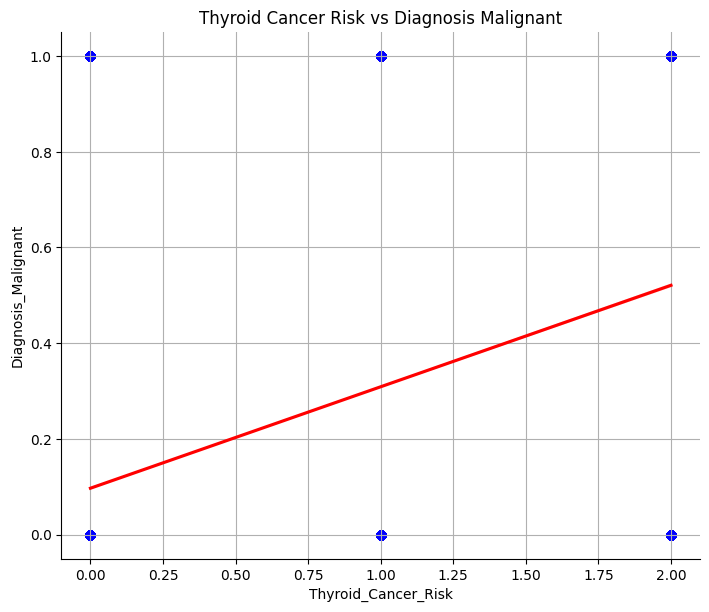

In [72]:
plt.figure(figsize=(10,5))
sns.lmplot(
    data=df2,
    x='Thyroid_Cancer_Risk',
    y='Diagnosis_Malignant',
    height=6,
    aspect=1.2,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)
plt.title('Thyroid Cancer Risk vs Diagnosis Malignant')
plt.grid(True)
plt.show()


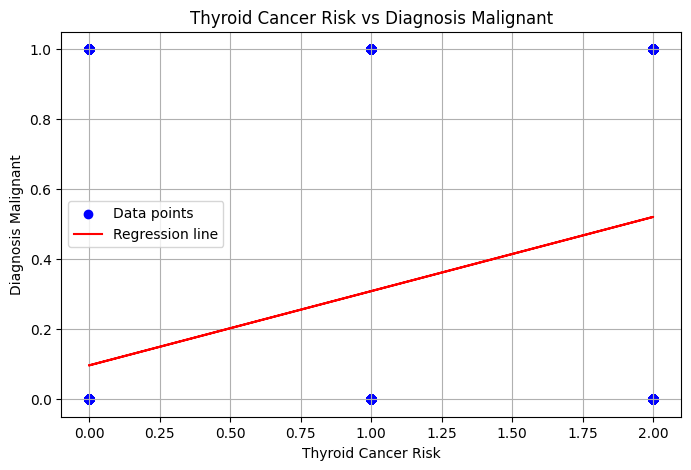

In [73]:
x = df2['Thyroid_Cancer_Risk']
y = df2['Diagnosis_Malignant']


slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept


plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, regression_line, color='red', label='Regression line')
plt.title("Thyroid Cancer Risk vs Diagnosis Malignant")
plt.xlabel("Thyroid Cancer Risk")
plt.ylabel("Diagnosis Malignant")
plt.grid(True)
plt.legend()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_7140\328909765.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


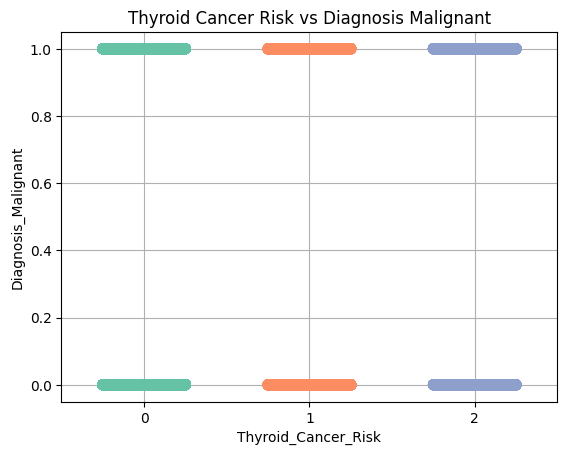

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.stripplot(
    data=df2,
    x='Thyroid_Cancer_Risk',
    y='Diagnosis_Malignant',
    jitter=0.25,        # Increase this if still overlapping
    size=8,             # Slightly larger points
    palette='Set2'
)
plt.title("Thyroid Cancer Risk vs Diagnosis Malignant")
plt.grid(True)
plt.show()



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Calculate Pearson Correlation
corr_value, _ = pearsonr(df2['Thyroid_Cancer_Risk'], df2['Family_History'])

# 2. Create scatter plot with regression line
plot = sns.lmplot(
    data=df2,
    x='Thyroid_Cancer_Risk',
    y= 'Family_History',
    height=6,
    aspect=1.2,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)

# 3. Add title and correlation value as text
plt.title('Thyroid Cancer Risk vs Family_History', fontsize=14, fontweight='bold')
plt.grid(True)

# Add correlation text inside the plot (adjust x/y as needed)
plt.text(
    x=1.2, y=0.8,  # Adjust depending on your data range
    s=f'Pearson Correlation: {corr_value:.2f}',
    fontsize=12,
    color='darkgreen',
    fontweight='bold'
)

plt.tight_layout()
plt.show()


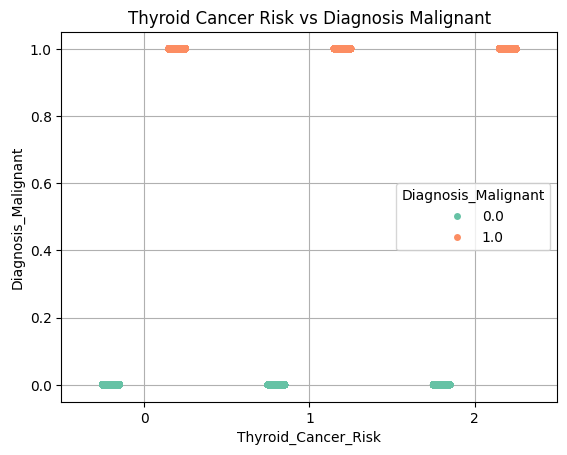

In [ ]:
sns.stripplot(
    data=df2,
    x='Thyroid_Cancer_Risk',
    y='Diagnosis_Malignant',
    hue='Diagnosis_Malignant',
    jitter=True,
    dodge=True,
    palette='Set2'
)
plt.title("Thyroid Cancer Risk vs Diagnosis Malignant")
plt.grid(True)
plt.show()


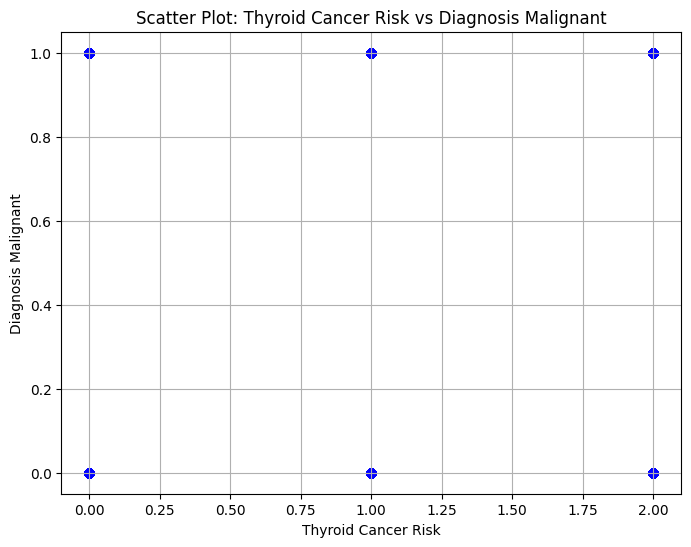

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(df2['Thyroid_Cancer_Risk'], df2['Diagnosis_Malignant'], color='blue', alpha=0.7)

plt.title('Scatter Plot: Thyroid Cancer Risk vs Diagnosis Malignant')
plt.xlabel('Thyroid Cancer Risk')
plt.ylabel('Diagnosis Malignant')
plt.grid(True)
plt.show()

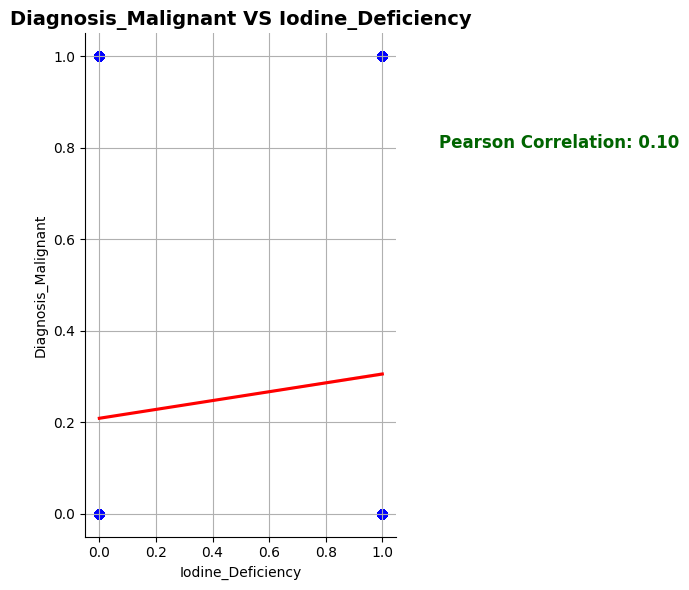

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Calculate Pearson Correlation
corr_value, _ = pearsonr(df2['Iodine_Deficiency'], df2['Diagnosis_Malignant'])

# 2. Create scatter plot with regression line
plot = sns.lmplot(
    data=df2,
    x='Iodine_Deficiency',
    y='Diagnosis_Malignant',
    height=6,
    aspect=1.2,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)

# 3. Add title and correlation value as text
plt.title('Diagnosis_Malignant VS Iodine_Deficiency', fontsize=14, fontweight='bold')
plt.grid(True)

# Add correlation text inside the plot (adjust x/y as needed)
plt.text(
    x=1.2, y=0.8,  # Adjust depending on your data range
    s=f'Pearson Correlation: {corr_value:.2f}',
    fontsize=12,
    color='darkgreen',
    fontweight='bold'
)

plt.tight_layout()
plt.show()


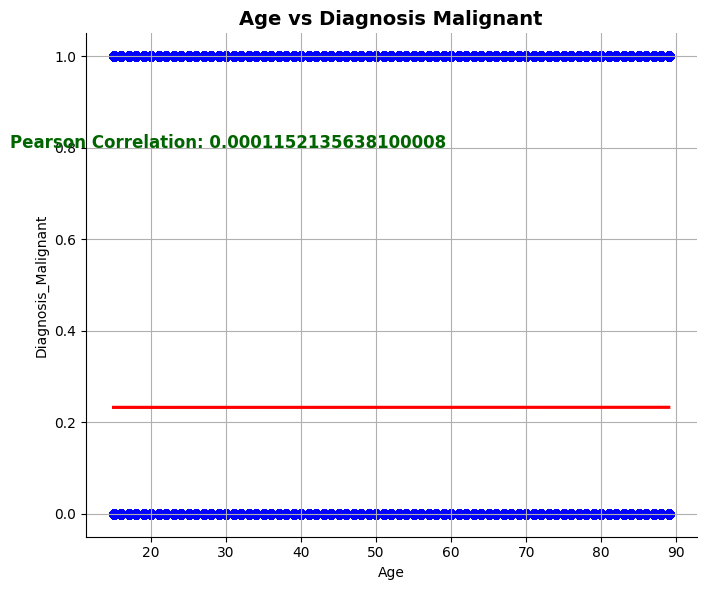

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Calculate Pearson Correlation
corr_value, _ = pearsonr(df2['Age'], df2['Diagnosis_Malignant'])

# 2. Create scatter plot with regression line
plot = sns.lmplot(
    data=df2,
    x='Age',
    y='Diagnosis_Malignant',
    height=6,
    aspect=1.2,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)

# 3. Add title and correlation value as text
plt.title('Age vs Diagnosis Malignant', fontsize=14, fontweight='bold')
plt.grid(True)

# Add correlation text inside the plot (adjust x/y as needed)
plt.text(
    x=1.2, y=0.8,  # Adjust depending on your data range
    s=f'Pearson Correlation: {corr_value}',
    fontsize=12,
    color='darkgreen',
    fontweight='bold'
)

plt.tight_layout()
plt.show()


In [ ]:
print(df2[['Thyroid_Cancer_Risk', 'Diagnosis_Malignant']].head(10))


   Thyroid_Cancer_Risk  Diagnosis_Malignant
0                    0                  0.0
1                    0                  0.0
2                    0                  0.0
3                    1                  0.0
4                    2                  0.0
5                    1                  0.0
6                    2                  1.0
7                    1                  0.0
8                    2                  1.0
9                    0                  0.0


## Correlation Analysis Summary  

The following table summarizes the key relationships among variables based on the correlation matrix. Only meaningful positive correlations (above **0.08**) have been included for clarity and focus.

| Feature               | Correlation with Thyroid_Cancer_Risk | Strength        | Type      |
|----------------------|----------------------------------------|-----------------|-----------|
| Family_History       | 0.239961                               | Weak            | Positive  |
| Radiation_Exposure   | 0.146727                               | Weak            | Positive  |
| Iodine_Deficiency    | 0.169618                               | Weak            | Positive  |
| TSH_Level            | 0.002494                               | Weak            | Positive  |
| T3_Level             | -0.000348                              | Weak            | Negative  |
| T4_Level             | 0.002761                               | Weak            | Positive  |
| Gender_Male          | -0.004816                              | Weak            | Negative  |
| Diagnosis_Malignant  | 0.365223                               | **Moderate**    | Positive  |
| Age                  | 0.003255                               | Weak            | Positive  |
| Smoking              | -0.001657                              | Weak            | Negative  |
| Obesity              | -0.002468                              | Weak            | Negative  |
| Diabetes             | -0.001021                              | Weak            | Negative  |
| Nodule_Size          | -0.000352                              | Weak            | Negative  |


---

##  CONCLUSION
- Most variables show **very weak or no correlation**, indicating minimal linear relationships.
- Features like **Smoking, Obesity, Diabetes, TSH, T3, T4, Age** do not show notable correlation with cancer risk or diagnosis.
- These insights help in **feature selection** for predictive modeling.



# 📌 Baseline Model in Machine Learning

## 1. What is a Baseline Model?
A baseline model is the simplest possible model that we create at the start of a machine learning project.  
It acts as a **reference point** to measure whether our later, more advanced models are actually improving performance.

---

## 2. Why Do We Use a Baseline Model?
- **Reference Point** → Helps compare future models and improvements.
- **Quick Start** → Gives an idea of how the model might perform with minimal effort.
- **Sanity Check** → Ensures there are no major issues in the dataset before complex modeling.
- **Error Benchmark** → Allows us to see how much error exists in the simplest form.

---

## 3. When Do We Build a Baseline Model?
- Always before doing complex feature engineering, parameter tuning, or advanced algorithms.
- At the start of **Supervised Learning** tasks (both classification & regression).

---

## 4. Types of Baseline Models

### a) For Classification:
1. **Most Frequent Class Model**
   - Predicts the most common category for all inputs.
2. **Simple ML Algorithm**
   - Logistic Regression, Decision Tree (with default parameters).

### b) For Regression:
1. **Mean/Median Model**
   - Predicts the mean/median of the target variable for all inputs.
2. **Simple Linear Regression** with default settings.

---

## 5. Benefits of Baseline Model
- Measures the **minimum acceptable performance**.
- Saves time — tells you quickly if your problem is feasible.
- Makes improvements measurable — you can say "We improved accuracy from 60% to 85%."

---

## 6. Key Note
- Baseline is **NOT** the final model.
- If your advanced model cannot beat the baseline → your approach needs rethinking.

---

## 7. Example:
If a dataset has:
- `Class A` → 80% data
- `Class B` → 20% data  
Then the baseline accuracy of predicting **Class A always** = **80%**.

If your ML model gives only 82% accuracy, then your model is only slightly better than baseline.


In [24]:
#Importing Necesaey Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd       
import numpy as np           
from sklearn.model_selection import train_test_split  #Will be used For splitting.....
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [25]:
df=pd.read_csv("encoded_thyroid_2.csv")

In [26]:
df.columns

Index(['Age', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency',
       'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level',
       'Nodule_Size', 'Thyroid_Cancer_Risk', 'Gender_Male',
       'Diagnosis_Malignant'],
      dtype='object')

#### **Input and Target Columns**

In [27]:
Y=df['Thyroid_Cancer_Risk']
Y

0         0
1         0
2         0
3         1
4         2
         ..
212686    0
212687    1
212688    1
212689    1
212690    0
Name: Thyroid_Cancer_Risk, Length: 212691, dtype: int64

In [28]:
drop_cols=['Age', 'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level',
       'Nodule_Size', 'Thyroid_Cancer_Risk', 'Gender_Male']
X=df.drop(drop_cols,axis=1)
X

,Family_History,Radiation_Exposure,Iodine_Deficiency,Diagnosis_Malignant
0,0,1,0,0.0
1,0,1,0,0.0
2,0,0,0,0.0
3,0,0,0,0.0
4,1,1,0,0.0
...,...,...,...,...
212686,0,0,0,0.0
212687,0,0,0,0.0
212688,0,0,0,0.0
212689,0,0,0,0.0


In [29]:
#Checking both X & Y
print("X shape:", X.shape)
print("y shape:", Y.shape)

X shape: (212691, 4)
y shape: (212691,)


### Why Do We Split the Dataset into Training and Testing Sets?

- When we apply Machine Learning, we usually start with only **one dataset**
- If we use the entire dataset for training, the model will see all the data and simply memorize it 
- In that case, when we check accuracy on the same data, the results will look very high, but in reality, the model has not truly learned , this is called **overfitting**.
- In the real world, our model will face **new and unseen data** (for example, new patients coming into the hospital) 
- But during the training phase, we do not yet have such new data 
- To solve this problem, we artificially split our available dataset into two parts:
1. **Training Set** – Used to teach the model patterns and relationships
2. **Testing Set** – Kept aside during training. The model never sees this data until the final evaluation, so it acts like *unseen* data
- This way, we can check whether the model has really learned to generalize, instead of just memorizing the training data

---

📌 **Analogy:**  
- Think of it like preparing for an exam
- If the teacher gives you all 100 questions with answers and then repeats the same questions in the exam, everyone will score 100% (memorization)
- But if the teacher teaches you 80 questions and then gives 20 *new* questions in the exam, your true understanding will be tested (generalization)

---

- Therefore, dataset splitting is necessary because in the beginning we don’t have new user data 
- We create a *pseudo unseen test set* by splitting our existing data

### Training vs Testing Split Guidelines

| Dataset Size            | Recommended Split | Reason                                                                 |
|--------------------------|-------------------|------------------------------------------------------------------------|
| **Very Large (100,000+)** | 90% Train / 10% Test OR 80% / 20% | Even 10% test set will have thousands of rows → enough for evaluation. |
| **Large (10,000 – 100,000)** | 80% Train / 20% Test OR 85% / 15% | Sufficient data for both training & testing.                           |
| **Medium (2,000 – 10,000)** | 75% Train / 25% Test OR 70% / 30% | Need larger test set for reliable evaluation.                          |
| **Small (< 2,000)**       | 70% Train / 30% Test               | More test data needed, otherwise test set too small.                   |
| **Very Small (< 500)**    | Use Cross-Validation instead        | Splitting may leave too little data → k-fold CV is better.             |

---

**Rule of Thumb**  
- Big dataset → **80/20**  
- Small dataset → **70/30**  
- Very small dataset → **Cross-validation**  
 For imbalanced datasets → always use **`stratify=Y`** in `train_test_split` to keep class ratio same.


| Random State | Training Rows  | Testing Rows |
| ------------ | -------------- | ------------ |
| 42           | 1,2,3,4,5,6,7  | 8,9,10       |
| 48           | 1,2,3,5,6,8,9  | 4,7,10       |
| 50           | 2,3,4,5,7,8,10 | 1,6,9        |


## **Training & Testing Split**

`Stratify=Y`
If our master data has a class split of 80/20, `stratifying` ensures that this proportion is maintained in both the training and test data. Equals Y tells the function that it should use the class ratio found in the Y variable, which is our target. The less data you have overall and the greater your class imbalance, the more important it is to stratify when you split the data. If we didn't stratify, then the function would split the data randomly. And we could get an unlucky split that doesn't get any of the minority class in the test data. In that case, we wouldn't be able to effectively evaluate our model. Worst of all, we might not even realize what went wrong without doing some detective work.

In [30]:
#80% used for training and 20% for testing
#features_train, features_test, labels_train, labels_test = train_test_split(X, Y, test_size=0.2)
#train_test_split returns 4 arrays so we take 4 variables , X_train, X_test, Y_train, Y_test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.2,       #20%
    random_state=42      #reproducability  ,  
    #random_state = 42 ya koi bhi number → ye ek seed hai jo random selection ko reproducible banata hai
    #Matlab: agar same random_state use karo, to har run me exact same rows training aur testing me jayenge
    #Agar random_state set na karo, to har run me training/testing alag-alag rows hongi → accuracy aur metrics slightly vary karenge
    #same seed == reproducable output.... value of random_state 42,50,78 does'nt matter
    #So random state affects which rows are chosen, not the percentage itself
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", Y_train.shape)
print("y_test shape:", Y_test.shape)




X_train shape: (170152, 4)
X_test shape: (42539, 4)
y_train shape: (170152,)
y_test shape: (42539,)


#### **Step: Training/Testing Set Distribution Check**

##### Purpose
- After splitting the dataset into training and testing sets, it is crucial to verify the distribution of the target column (`Y`) in both sets
- This ensures that the **proportion of each class** remains roughly the same as in the original dataset.

##### Why We Check This
1. **Class Balance Verification:**  
   - If the target column is imbalanced (e.g. Low = 50%, Medium = 34%, High = 15%), we need to make sure both training and testing sets reflect this proportion.
2. **Model Reliability:**  
   - Uneven class distribution between training and testing sets can lead to biased predictions and misleading accuracy scores.
3. **Debugging:**  
   - Confirms that the train/test split worked as intended and no class is missing in either set.

##### What We Compare
- Compare **each set's class distribution with the original dataset's target distribution**.  
- Ideally, the training and testing sets should maintain the same approximate proportions as the original dataset.  
- Minor differences are acceptable, but large deviations may indicate a poor split.

##### How to Handle Major Differences
- If you notice **major differences** between training/testing distributions or compared to the original dataset:

| Issue | Possible Reason | Solution |
|-------|----------------|---------|
| A class is missing in testing or training set | Random splitting can sometimes exclude rare classes | Use `stratify=Y` in `train_test_split()` to maintain class proportions |
| One class is overrepresented | Random split without stratification | Again, `stratify=Y` ensures proportional representation |
| Both sets heavily differ from original distribution | Small dataset or highly imbalanced classes | Consider **oversampling/undersampling** or using techniques like **SMOTE** for training |

#### **Target Distribution Verification**

In [31]:
print("Training set distribution:")
print(Y_train.value_counts(normalize=True) * 100)

print("\nTesting set distribution:")
print(Y_test.value_counts(normalize=True) * 100)


Training set distribution:
Thyroid_Cancer_Risk
0    50.951502
1    34.058959
2    14.989539
Name: proportion, dtype: float64

Testing set distribution:
Thyroid_Cancer_Risk
0    50.995557
1    33.964127
2    15.040316
Name: proportion, dtype: float64


##### Understanding **normalize=True** vs Feature Normalization

---

##### 1. `normalize=True` in `value_counts()`

- When we check the class distribution of the target column using `value_counts()`, by default it gives **counts** of each class


##### Without normalize:
- Low       3
- Medium    2
- High      1

##### With normalize=True:
- Low       0.5000   → 50%
- Medium    0.3333   → 33.3%
- High      0.1667   → 16.7%




## **Model Training**

In [32]:
#-------------Model ka object creation
log_reg_model = LogisticRegression(max_iter=1000)  

#-------------Training data par model fitting
#-----is the step where the model actually learns patterns from training data
#and builds the mathematical relationship between features (X) and target (Y)
log_reg_model.fit(X_train, Y_train) 



# Logistic Regression Model Initialization
# LogisticRegression(max_iter=1000)` creates an **object of the LogisticRegression class** (an empty model)
# At this stage, only the **algorithm structure and hyperparameters** are set; the model hasn’t learned anything yet
# The actual learning happens when we call `.fit(X_train, Y_train)`
# `max_iter` defines the maximum number of iterations the model will run to find the best solution  
# The default is 100, but for more complex datasets, we often increase it to **1000 or more**


LogisticRegression(max_iter=1000)

### **Prediction / Inference Phase**

In [33]:
#-------PREDICTION ON TESTING DATA
y_pred = log_reg_model.predict(X_test)

#Training Phase: Model has already “seen” X_train, Y_train → it has learned from them.
#Testing Phase: We want to check generalization ability of the model i.e. how well it performs on unseen data (X_test)
#If we predict on training data, it will just repeat what it already memorized → no real test of performance

#-----------40 PREDICTIONS
print("Predictions:", y_pred[:40])
print("Actual:", Y_test[:40].values)




# Training: X_train → model → predicts something → compared with Y_train (to adjust weights)
# Testing (evaluation): X_test → model → y_pred (model’s guess)
#Then we compare y_pred with Y_test to check accuracy
# Is liye predict function hamesha X_test par hota hai.
# Y_test bas baad me use hota hai as a reference/benchmark.

Predictions: [2 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 0 0 0 0 0
 0 0 0]
Actual: [0 2 1 0 1 0 0 2 2 1 0 0 0 0 1 0 0 0 0 1 1 0 2 1 1 1 1 1 0 2 0 0 0 1 0 0 1
 0 0 0]


In [34]:
#------UNIQUE PREDICTED VALUES
unique, counts = np.unique(y_pred, return_counts=True)
percentages = counts / len(y_pred) * 100

for u, c, p in zip(unique, counts, percentages):
    print(f"Class {u}: {c} predictions ({p:.2f}%)")


Class 0: 35317 predictions (83.02%)
Class 2: 7222 predictions (16.98%)


### **Accuracy Measurment**

##### **Accuracy = Correct predictions / Total No of predictions**

In [35]:

accuracy = accuracy_score(Y_test, y_pred)
# Accuracy = Total Number of Predictions / Number of Correct Predictions​

# Classification report (includes precision, recall, f1-score)
#class_report = classification_report(Y_test, y_pred)

# Confusion matrix
conf_matrix = confusion_matrix(Y_test, y_pred)

print("Accuracy:", accuracy)
#print("\nClassification Report:\n", class_report)
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 0.5778462117116058

Confusion Matrix:
 [[20059     0  1634]
 [13382     0  1066]
 [ 1876     0  4522]]


| Index | Actual (Y\_test) | Predicted (y\_pred) | Correct? |
| ----- | ---------------- | ------------------- | -------- |
| 1     | Low              | Low                 | ✅        |
| 2     | Low              | Medium              | ❌        |
| 3     | High             | High                | ✅        |
| 4     | Medium           | Medium              | ✅        |
| 5     | Medium           | Low                 | ❌        |
| 6     | Low              | Low                 | ✅        |
| 7     | High             | Low                 | ❌        |
| 8     | Medium           | Medium              | ✅        |
| 9     | Low              | Low                 | ✅        |
| 10    | High             | High                | ✅        |

- Correct Predictions = 7
- Wrong Predictions = 3
- Total = 10  ,   Accuracy = 7/10=70%


##### Question  
- Why does my model's accuracy (~0.519) look so close to the percentage of the majority class (≈51% "Low") in my dataset?  

---

##### Answer  
- This happens because of **class imbalance**
- When one class dominates (e.g. "Low" = 51%), even a naive model that **always predicts "Low"** will reach ~51% accuracy
- This is called the **Accuracy Paradox** when the model may seem correct, but it’s not truly learning patterns  

---

##### Key Point  
- In imbalanced datasets, **accuracy alone is misleading**
- Instead, you should also check:  
- Confusion Matrix  
- Precision, Recall, F1-score  
- Balanced Accuracy  


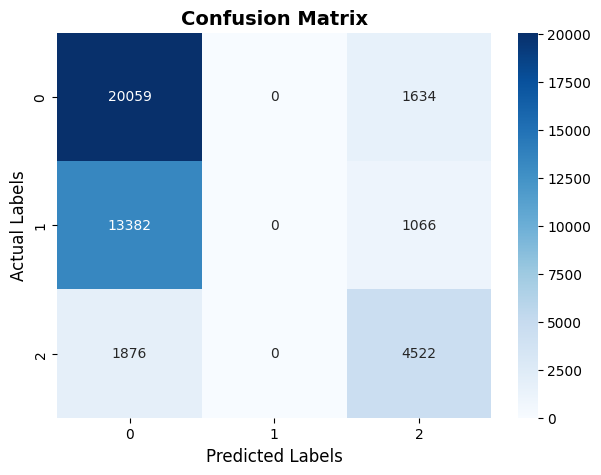

In [36]:
# Step 1: Confusion Matrix create
cm = confusion_matrix(Y_test, y_pred)

# Step 2: Labels for axes
labels = [0,1,2]


plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.show()

##### **Decision Tree**

In [45]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)
y_pred_dt = dt_model.predict(X_test)


print("Decision Tree Results")
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))
#print("\nClassification Report:\n", classification_report(Y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.5781047979501164
Confusion Matrix:
 [[20152     0  1541]
 [13464     0   984]
 [ 1958     0  4440]]


In [38]:
#------UNIQUE PREDICTED VALUES
unique, counts = np.unique(y_pred_dt, return_counts=True)
percentages = counts / len(y_pred_dt) * 100

for u, c, p in zip(unique, counts, percentages):
    print(f"Class {u}: {c} predictions ({p:.2f}%)")


Class 0: 35574 predictions (83.63%)
Class 2: 6965 predictions (16.37%)


#### **XGB Classifier**

In [39]:
xgb_model = XGBClassifier(
    random_state=42,
    #use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, Y_train)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate
print("XGBoost Results")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
#print("\nClassification Report:\n", classification_report(Y_test, y_pred_xgb))
#print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_xgb))


XGBoost Results
Accuracy: 0.5781047979501164


In [40]:
#------UNIQUE PREDICTED VALUES
unique, counts = np.unique(y_pred_xgb, return_counts=True)
percentages = counts / len(y_pred_xgb) * 100

for u, c, p in zip(unique, counts, percentages):
    print(f"Class {u}: {c} predictions ({p:.2f}%)")


Class 0: 35574 predictions (83.63%)
Class 2: 6965 predictions (16.37%)


##### Oversampling minority classes
- Example: SMOTE (Synthetic Minority Oversampling Technique)
- Increases samples of “Medium” & “High” classes
##### Undersampling majority class
- Reduces “Low” samples so dataset becomes balanced
- Risk: losing information
##### Combination (Hybrid)
- Balance by undersampling majority a little and oversampling minority.
##### Use Class Weights
- Many ML models (Logistic Regression, Decision Tree, XGBoost) allow you to give higher weight to minority classes, instead of changing dataset size

In [46]:
from imblearn.over_sampling import SMOTE
from collections import Counter



#---------SMOTE Initialization
smote = SMOTE(random_state=42)

#---------Apply SMOTE on training data only
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train) # type: ignore

#---------Verify new class distribution
print("Original Training Class Distribution:")
print(Y_train.value_counts(normalize=True) * 100)

print("\nResampled Training Class Distribution:")
print(Y_train_resampled.value_counts(normalize=True) * 100)


Original Training Class Distribution:
Thyroid_Cancer_Risk
0    50.951502
1    34.058959
2    14.989539
Name: proportion, dtype: float64

Resampled Training Class Distribution:
Thyroid_Cancer_Risk
0    33.333333
2    33.333333
1    33.333333
Name: proportion, dtype: float64


In [47]:
# XGBoost model training (on SMOTE resampled data)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_resampled, Y_train_resampled )

# Prediction on untouched test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Results")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_xgb))


C:\Users\Hp\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [11:20:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
Accuracy: 0.5072991842779567

Confusion Matrix:
 [[12251  6228  3214]
 [ 8145  4168  2135]
 [  417   820  5161]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.56      0.58     21693
           1       0.37      0.29      0.32     14448
           2       0.49      0.81      0.61      6398

    accuracy                           0.51     42539
   macro avg       0.48      0.55      0.50     42539
weighted avg       0.50      0.51      0.50     42539



In [48]:
# Train Decision Tree with class_weight
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_model.fit(X_train, Y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Results with Class Weights")
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))
print(classification_report(Y_test, y_pred_dt))

Decision Tree Results with Class Weights
Accuracy: 0.5072991842779567
              precision    recall  f1-score   support

           0       0.59      0.56      0.58     21693
           1       0.37      0.29      0.32     14448
           2       0.49      0.81      0.61      6398

    accuracy                           0.51     42539
   macro avg       0.48      0.55      0.50     42539
weighted avg       0.50      0.51      0.50     42539



In [49]:
import numpy as np

# Calculate class weights manually
from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight="balanced", y=Y_train)

# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, Y_train, sample_weight=weights)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Results with Class Weights")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print(classification_report(Y_test, y_pred_xgb))

C:\Users\Hp\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [11:21:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results with Class Weights
Accuracy: 0.5072991842779567
              precision    recall  f1-score   support

           0       0.59      0.56      0.58     21693
           1       0.37      0.29      0.32     14448
           2       0.49      0.81      0.61      6398

    accuracy                           0.51     42539
   macro avg       0.48      0.55      0.50     42539
weighted avg       0.50      0.51      0.50     42539



#### **Types of Categorical Data in Machine Learning**

- Categorical columns contain **discrete values** that represent different categories. They are mainly divided into two types:

---

### 1. **Nominal Categorical Data (Unordered Categories)**

- These are **categories that have no inherent order or ranking**.
- Each category is **independent** and cannot be compared as greater or smaller.

📌 **Examples:**
- `Gender`: Male, Female
- `Country`: Pakistan, India, Germany, Canada


---

### 2. **Ordinal Categorical Data (Ordered Categories)**

- These are **categories that follow a logical order or ranking**.
- But the **difference between ranks is not necessarily equal**.

📌 **Examples:**
- `Thyroid_Cancer_Risk`: Low, Medium, High
- `Education_Level`: High School, Bachelor's, Master's, PhD


---

### ❗ Why This Classification Matters?

- **Nominal** data: We use One-Hot Encoding to avoid implying any order.
- **Ordinal** data: We preserve the order using encoding that reflects hierarchy.

Correct classification is very important for selecting the **right encoding technique**.


| Situation                    | Best Encoding Technique       |
| ---------------------------- | ----------------------------- |
| Nominal (few categories)     | One-Hot Encoding              |
| Nominal (many categories)    | Frequency / Target Encoding   |
| Ordinal (natural order)      | Label Encoding                |
| Tree-based model + any data  | Label / Frequency Encoding OK |
| Linear models + nominal data | ❌ Avoid Label Encoding       |


#### **`Correlation Cofficients`**

| Correlation Coefficient | Correlation Strength | Correlation Type |
|-------------------------|----------------------|------------------|
| -0.7 to -1             | Very Strong          | Negative         |
| -0.5 to -0.7           | Strong               | Negative         |
| -0.3 to -0.5           | Moderate             | Negative         |
|  0 to -0.3             | Weak                 | Negative         |
|  0                    | None                 | Zero             |
|  0 to 0.3              | Weak                 | Positive         |
|  0.3 to 0.5            | Moderate             | Positive         |
|  0.5 to 0.7            | Strong               | Positive         |
|  0.7 to 1              | Very Strong          | Positive         |


| Correlation Coefficient     | Type of Relationship | Levels of Measurement                                                   | Data Distribution      |
|-----------------------------|-----------------------|--------------------------------------------------------------------------|------------------------|
| Pearson’s r                 | Linear                | Two quantitative (interval or ratio) variables                           | Normal distribution    |
| Spearman’s rho              | Non-linear            | Two ordinal, interval or ratio variables                                 | Any distribution       |
| Point-biserial              | Linear                | One dichotomous (binary) variable and one quantitative (interval/ratio)  | Normal distribution    |
| Cramér’s V (Cramér’s φ)     | Non-linear            | Two nominal variables                                                    | Any distribution       |
| Kendall’s tau               | Non-linear            | Two ordinal, interval or ratio variables                                 | Any distribution       |


``` python
# Feature Importance
feature_importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(12, 6))
plt.barh(feature_names, feature_importances, color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()
plt.show()

### Feature Normalization — Is it Necessary?

| Algorithm Type          | Examples                              | Normalization Needed? |
|-------------------------|---------------------------------------|------------------------|
| Distance-based Models   | KNN, K-Means, SVM                     | ✅ Yes                 |
| Gradient-based Models   | Logistic Regression, Neural Networks  | ✅ Yes                 |
| Tree-based Models       | Decision Trees, Random Forest, XGBoost| ❌ No                  |

---

### When to Perform?
- After **Train/Test Split**  
- Apply scaler on `X_train`, then use the same scaler to transform `X_test`.  
- Prevents **data leakage**.  



### Understanding the Confusion Matrix

- Each **row** represents the actual class, and the **row sum** equals the total number of cases for that class.  
  Example: For the "Low" class → `5853 + 6216 + 9624 = 21693` actual cases.

- The **diagonal values** represent correct predictions for each class, while the off-diagonal values represent misclassifications.  
  Example: `5853` = correctly predicted "Low", while `6216` = misclassified "Low" as "Medium".

- If the diagonal value in a row is **much higher than the off-diagonal values**, it means the model is recognizing that class well.  
  If the diagonal is lower than the misclassifications, the model is struggling with that class.

👉 In short: Rows = actual classes, diagonals = correct predictions, and the balance between diagonal vs. off-diagonal tells us which classes the model handles well or poorly.
